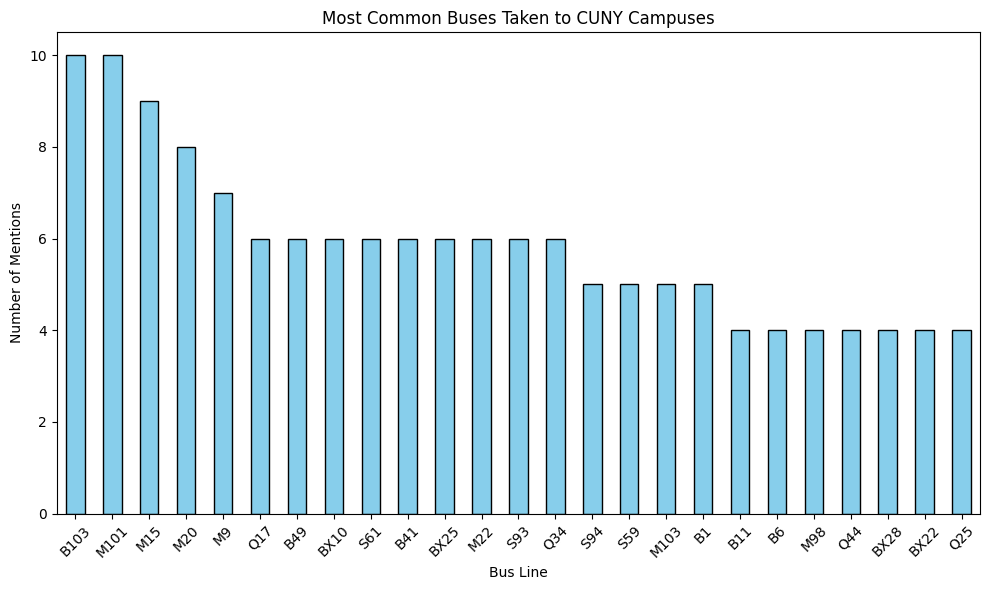

Top Bus Counts:
B103    10
M101    10
M15      9
M20      8
M9       7
Q17      6
B49      6
BX10     6
S61      6
B41      6
BX25     6
M22      6
S93      6
Q34      6
S94      5
S59      5
M103     5
B1       5
B11      4
B6       4
M98      4
Q44      4
BX28     4
BX22     4
Q25      4
Name: count, dtype: int64


In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt


file_path = "CUNY BUS SURVEY (Responses) - Form Responses 1.csv"
df = pd.read_csv(file_path)


bus_col = "Which bus or buses can you take to get to campus"


def normalize_bus(bus_str):
    parts = re.split(r"[,&/]| and |;|\s+", str(bus_str).lower())
    clean_parts = []
    for p in parts:
        p = p.strip().upper()
        if re.match(r"^[A-Z]+\d+$", p):
            clean_parts.append(p)
    return clean_parts


all_buses = []
for entry in df[bus_col].dropna():
    all_buses.extend(normalize_bus(entry))

bus_counts = pd.Series(all_buses).value_counts()


top_n = 25
bus_counts_top = bus_counts.head(top_n)

plt.figure(figsize=(10,6))
bus_counts_top.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Most Common Buses Taken to CUNY Campuses")
plt.xlabel("Bus Line")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("Top Bus Counts:")
print(bus_counts_top)


In [2]:
#Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')



In [3]:
#Define CUNY routes mapping
cuny_routes = {
    "Hunter College": ["M15", "M98", "M101", "M103"],
    "Brooklyn College": ["B11", "B41", "B49", "B103","B6"], 
    "Queens College": ["Q17", "Q25", "Q34", "Q44+"],
    "Lehman College": ["BX10", "BX28", "BX22", "BX25"],
    "College of Staten Island": ["S93", "S61", "S94", "S59"],
    "BMCC": ["M20", "M9", "M22"],
    "Kingsborough CC": ["B1", "B49"]
}

all_cuny_routes = []
campus_map = {}
for campus, routes in cuny_routes.items():
    all_cuny_routes.extend(routes)
    for route in routes:
        campus_map[route] = campus

print(f"Tracking {len(all_cuny_routes)} CUNY routes across {len(cuny_routes)} campuses")

Tracking 26 CUNY routes across 7 campuses


In [4]:
#Data loading and preprocessing
print("\nSECTION 1: DATA LOADING")
print("=" * 50)

try:
    
    pre_ace_speeds = pd.read_csv('MTA_Bus_Speeds__2015-2019_20250919.csv')
    
     
    current_speeds = pd.read_csv('MTA_Bus_Route_Segment_Speeds__Beginning_2025_20250917.csv')
    
   
    ace_routes_df = pd.read_csv('MTA_Bus_Automated_Camera_Enforced_Routes__Beginning_October_2019_20250919.csv')
    
    print(f"Pre-ACE speeds (2015-2019): {pre_ace_speeds.shape}")
    print(f"Current speeds (2025): {current_speeds.shape}")
    print(f"ACE implementation data: {ace_routes_df.shape}")
    
    print(f"\nPre-ACE columns: {list(pre_ace_speeds.columns)}")
    print(f"Current columns: {list(current_speeds.columns)}")
    print(f"ACE columns: {list(ace_routes_df.columns)}")
    
except Exception as e:
    print(f"Error loading data: {e}")
    exit()


SECTION 1: DATA LOADING
Pre-ACE speeds (2015-2019): (68716, 9)
Current speeds (2025): (3411549, 24)
ACE implementation data: (64, 3)

Pre-ACE columns: ['month', 'borough', 'day_type', 'trip_type', 'route_id', 'period', 'total_operating_time', 'total_mileage', 'average_speed']
Current columns: ['Year', 'Month', 'Timestamp', 'Day of Week', 'Hour of Day', 'Route ID', 'Direction', 'Borough', 'Route Type', 'Stop Order', 'Timepoint Stop ID', 'Timepoint Stop Name', 'Timepoint Stop Latitude', 'Timepoint Stop Longitude', 'Next Timepoint Stop ID', 'Next Timepoint Stop Name', 'Next Timepoint Stop Latitude', 'Next Timepoint Stop Longitude', 'Road Distance', 'Average Travel Time', 'Average Road Speed', 'Bus Trip Count', 'Timepoint Stop Georeference', 'Next Timepoint Stop Georeference']
ACE columns: ['Route', 'Program', 'Implementation Date']


In [5]:
#ACE routes identification
print("\n" + "="*50)
print("SECTION 2: IDENTIFY ACE ROUTES AND IMPLEMENTATION DATES")
print("="*50)


ace_data = ace_routes_df.copy()


route_col = 'Route' if 'Route' in ace_data.columns else ace_data.columns[0]
impl_date_col = 'Implementation Date' if 'Implementation Date' in ace_data.columns else None

if impl_date_col is None:
    date_cols = [col for col in ace_data.columns if 'date' in col.lower() or 'implementation' in col.lower()]
    if date_cols:
        impl_date_col = date_cols[0]

print(f"Using route column: {route_col}")
print(f"Using implementation date column: {impl_date_col}")


if impl_date_col:
    ace_data['implementation_date'] = pd.to_datetime(ace_data[impl_date_col], errors='coerce')
    ace_data = ace_data.dropna(subset=['implementation_date'])
    
    print(f"ACE routes with valid implementation dates: {len(ace_data)}")
    print(f"Implementation date range: {ace_data['implementation_date'].min()} to {ace_data['implementation_date'].max()}")
else:
    print("No implementation date column found - using default October 2019")
    ace_data['implementation_date'] = pd.to_datetime('2019-10-01')


def clean_route_name(route):
    if pd.isna(route):
        return None
    route_str = str(route).strip().upper()
    route_str = route_str.replace('BUS', '').replace('ROUTE', '').strip()
    return route_str

ace_data['route_clean'] = ace_data[route_col].apply(clean_route_name)
ace_routes_dict = dict(zip(ace_data['route_clean'], ace_data['implementation_date']))

print(f"Sample ACE routes: {list(ace_routes_dict.keys())[:10]}")


SECTION 2: IDENTIFY ACE ROUTES AND IMPLEMENTATION DATES
Using route column: Route
Using implementation date column: Implementation Date
ACE routes with valid implementation dates: 64
Implementation date range: 2019-10-07 00:00:00 to 2025-09-15 00:00:00
Sample ACE routes: ['M15+', 'B44+', 'M14+', 'B46+', 'M23+', 'M86+', 'M34+', 'Q44+', 'S79+', 'BX41+']


In [6]:

print("\n" + "="*50) 
print("SECTION 3: PROCESS PRE-ACE BASELINE SPEEDS (2015-2019)")
print("="*50)


pre_route_col = None
pre_speed_col = None
pre_date_col = None

for col in pre_ace_speeds.columns:
    if 'route' in col.lower():
        pre_route_col = col
    elif 'speed' in col.lower() and 'average' in col.lower():
        pre_speed_col = col
    elif 'month' in col.lower() or 'date' in col.lower():
        pre_date_col = col

print(f"Pre-ACE route column: {pre_route_col}")
print(f"Pre-ACE speed column: {pre_speed_col}")
print(f"Pre-ACE date column: {pre_date_col}")

if not all([pre_route_col, pre_speed_col]):
    print("Critical columns missing in pre-ACE dataset")
    exit()


pre_data = pre_ace_speeds[[pre_route_col, pre_speed_col]].copy()
if pre_date_col:
    pre_data[pre_date_col] = pre_ace_speeds[pre_date_col]

pre_data.columns = ['route', 'speed'] + (['date'] if pre_date_col else [])
pre_data = pre_data.dropna(subset=['route', 'speed'])


pre_data['route_clean'] = pre_data['route'].apply(clean_route_name)


pre_ace_baseline = pre_data.groupby('route_clean')['speed'].mean().reset_index()
pre_ace_baseline.columns = ['route', 'pre_ace_speed']

print(f"Pre-ACE baseline calculated for {len(pre_ace_baseline)} routes")
print(f"Pre-ACE speed range: {pre_ace_baseline['pre_ace_speed'].min():.1f} - {pre_ace_baseline['pre_ace_speed'].max():.1f} mph")


SECTION 3: PROCESS PRE-ACE BASELINE SPEEDS (2015-2019)
Pre-ACE route column: route_id
Pre-ACE speed column: average_speed
Pre-ACE date column: month
Pre-ACE baseline calculated for 532 routes
Pre-ACE speed range: 3.0 - 30.0 mph


In [7]:
#Post-ACE speeds processing
print("\n" + "="*50)
print("SECTION 4: PROCESS POST-ACE SPEEDS (2025)")
print("="*50)


curr_route_col = 'Route ID' if 'Route ID' in current_speeds.columns else 'route'
curr_speed_col = 'Average Road Speed' if 'Average Road Speed' in current_speeds.columns else None

if not curr_speed_col:
    speed_cols = [col for col in current_speeds.columns if 'speed' in col.lower()]
    curr_speed_col = speed_cols[0] if speed_cols else None

print(f"Current route column: {curr_route_col}")  
print(f"Current speed column: {curr_speed_col}")

if not curr_speed_col:
    print("Speed column not found in current dataset")
    exit()


current_route_speeds = current_speeds.groupby(curr_route_col)[curr_speed_col].mean().reset_index()
current_route_speeds.columns = ['route', 'current_speed']
current_route_speeds['route_clean'] = current_route_speeds['route'].apply(clean_route_name)


post_ace_data = current_route_speeds.groupby('route_clean')['current_speed'].mean().reset_index()
post_ace_data.columns = ['route', 'post_ace_speed']

print(f"Post-ACE speeds calculated for {len(post_ace_data)} routes")
print(f"Post-ACE speed range: {post_ace_data['post_ace_speed'].min():.1f} - {post_ace_data['post_ace_speed'].max():.1f} mph")


SECTION 4: PROCESS POST-ACE SPEEDS (2025)
Current route column: Route ID
Current speed column: Average Road Speed
Post-ACE speeds calculated for 370 routes
Post-ACE speed range: 5.4 - 19.0 mph


In [8]:
#Data merging and classification
print("\n" + "="*50)
print("SECTION 5: MERGE DATA AND CLASSIFY ROUTES") 
print("="*50)


analysis_data = pd.merge(pre_ace_baseline, post_ace_data, on='route', how='inner')
print(f"Routes with both pre and post data: {len(analysis_data)}")


analysis_data['has_ace'] = analysis_data['route'].isin(ace_routes_dict.keys())
analysis_data['implementation_date'] = analysis_data['route'].map(ace_routes_dict)


analysis_data['speed_change'] = analysis_data['post_ace_speed'] - analysis_data['pre_ace_speed'] 
analysis_data['speed_change_pct'] = (analysis_data['speed_change'] / analysis_data['pre_ace_speed']) * 100


analysis_data['is_cuny'] = analysis_data['route'].isin([r.upper() for r in all_cuny_routes])
analysis_data['campus'] = analysis_data['route'].map(lambda x: campus_map.get(x, 'Non-CUNY'))


ace_routes_analysis = analysis_data[analysis_data['has_ace'] == True].copy()
non_ace_routes_analysis = analysis_data[analysis_data['has_ace'] == False].copy()

print(f"ACE routes in analysis: {len(ace_routes_analysis)}")
print(f"Non-ACE routes in analysis: {len(non_ace_routes_analysis)}")


SECTION 5: MERGE DATA AND CLASSIFY ROUTES
Routes with both pre and post data: 330
ACE routes in analysis: 42
Non-ACE routes in analysis: 288


In [17]:
#Define exempt statuses and setup
exempt_statuses = [
    "EXEMPT - BUS/PARATRANSIT",
    "EXEMPT - COMMERCIAL UNDER 20", 
    "EXEMPT - EMERGENCY VEHICLE",
    "EXEMPT - OTHER",
   
]

print("Exempt status categories defined:")
for status in exempt_statuses:
    print(f"• {status}")

Exempt status categories defined:
• EXEMPT - BUS/PARATRANSIT
• EXEMPT - COMMERCIAL UNDER 20
• EXEMPT - EMERGENCY VEHICLE
• EXEMPT - OTHER


In [18]:
#Data Loading and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


print("SECTION 1: DATA LOADING")
print("=" * 40)

print("Loading full dataset...")

try:
    
    df_full = pd.read_csv(
        'MTA_Bus_Automated_Camera_Enforcement_Violations__Beginning_October_2019_20250922.csv',
        usecols=['Vehicle ID', 'Violation Status', 'Violation Type', 'Bus Route ID', 
                'Violation Latitude', 'Violation Longitude', 'First Occurrence'],
        dtype={
            'Vehicle ID': 'str', 
            'Violation Status': 'str',
            'Violation Type': 'str',
            'Bus Route ID': 'str',
            'Violation Latitude': 'float64',
            'Violation Longitude': 'float64'
        }
    )
    
    print(f"Loaded {len(df_full):,} total records")
    
   
    df_exempt = df_full[df_full['Violation Status'].str.contains("exempt", case=False, na=False)]
    
    print(f"Found {len(df_exempt):,} exempt violations")

except Exception as e:
    print(f"Error: {e}")
    df_exempt = pd.DataFrame()

if len(df_exempt) == 0:
    print("No data to analyze")
    exit()

print(f"Final dataset: {len(df_exempt):,} exempt violations")

SECTION 1: DATA LOADING
Loading full dataset...
Loaded 3,778,568 total records
Found 870,810 exempt violations
Final dataset: 870,810 exempt violations


In [19]:
#Repeat Offender Analysis
print("\nSECTION 2: REPEAT OFFENDER ANALYSIS")
print("=" * 40)

print("Analyzing repeat offenders...")
vehicle_counts = df_exempt['Vehicle ID'].value_counts()

total_vehicles = len(vehicle_counts)
repeat_vehicles = (vehicle_counts > 1).sum()
chronic_vehicles = (vehicle_counts >= 25).sum()

print(f"Total exempt vehicles: {total_vehicles:,}")
print(f"Repeat offenders: {repeat_vehicles:,} ({repeat_vehicles/total_vehicles*100:.1f}%)")
print(f"Chronic offenders (25+): {chronic_vehicles:,} ({chronic_vehicles/total_vehicles*100:.1f}%)")

print(f"\nViolation distribution:")
dist = vehicle_counts.value_counts().head(10)
for viol, cnt in dist.items():
    print(f"  {viol} violation{'s' if viol != 1 else ''}: {cnt:,} vehicles")

print(f"\nTop 10 repeat offenders:")
top = vehicle_counts.head(10)
for vid, cnt in top.items():
    print(f"  {vid[:10]}***: {cnt} violations")


SECTION 2: REPEAT OFFENDER ANALYSIS
Analyzing repeat offenders...
Total exempt vehicles: 154,123
Repeat offenders: 72,330 (46.9%)
Chronic offenders (25+): 6,107 (4.0%)

Violation distribution:
  1 violation: 81,793 vehicles
  2 violations: 21,668 vehicles
  3 violations: 11,210 vehicles
  4 violations: 6,811 vehicles
  5 violations: 4,930 vehicles
  6 violations: 3,791 vehicles
  7 violations: 2,895 vehicles
  8 violations: 2,259 vehicles
  9 violations: 1,864 vehicles
  10 violations: 1,597 vehicles

Top 10 repeat offenders:
  479d603cb0***: 1377 violations
  1feaad876c***: 1346 violations
  6d7caef8bf***: 949 violations
  6979a2434b***: 924 violations
  2a8ac01b15***: 915 violations
  e020820037***: 894 violations
  ebabc58528***: 842 violations
  cbebd9b5a6***: 782 violations
  550bbcf6f5***: 725 violations
  80e7bae594***: 691 violations


In [20]:
#Geographic Hotspot Analysis
print("\nSECTION 3: GEOGRAPHIC HOTSPOT ANALYSIS")
print("=" * 40)

sample_size = min(20000, len(df_exempt))
print(f"Using {sample_size:,} sample for geo analysis...")


geo_sample = pd.DataFrame()
cluster_df = pd.DataFrame()

if sample_size > 0:
    geo_sample = df_exempt.dropna(subset=['Violation Latitude', 'Violation Longitude']).sample(
        n=min(sample_size, len(df_exempt.dropna(subset=['Violation Latitude', 'Violation Longitude']))), 
        random_state=42
    )
    
    if len(geo_sample) > 5:  
        coords = geo_sample[['Violation Latitude', 'Violation Longitude']].values
        
        scaler = StandardScaler()
        coords_scaled = scaler.fit_transform(coords)
        
        kmeans = KMeans(n_clusters=5, random_state=42, n_init=5)
        clusters = kmeans.fit_predict(coords_scaled)
        geo_sample['Cluster'] = clusters
        
        cluster_stats = []
        for i in range(5):
            cluster_data = geo_sample[geo_sample['Cluster'] == i]
            if len(cluster_data) > 0:
                cluster_stats.append({
                    'Cluster': i,
                    'Count': len(cluster_data),
                    'Lat': cluster_data['Violation Latitude'].mean(),
                    'Lon': cluster_data['Violation Longitude'].mean(),
                    'Main_Status': cluster_data['Violation Status'].mode().iloc[0]
                })
        
        cluster_df = pd.DataFrame(cluster_stats).sort_values('Count', ascending=False)
        
        print(f"Top violation hotspots:")
        for _, row in cluster_df.iterrows():
            print(f"Cluster {row['Cluster']}: {row['Count']:,} violations at ({row['Lat']:.3f}, {row['Lon']:.3f})")
            print(f"  Primary status: {row['Main_Status']}")
    else:
        print("Insufficient geographic data for clustering")
else:
    print("No geographic data available")


SECTION 3: GEOGRAPHIC HOTSPOT ANALYSIS
Using 20,000 sample for geo analysis...
Top violation hotspots:
Cluster 3: 5,809 violations at (40.805, -73.942)
  Primary status: EXEMPT - EMERGENCY VEHICLE
Cluster 0: 4,727 violations at (40.734, -73.981)
  Primary status: EXEMPT - EMERGENCY VEHICLE
Cluster 1: 4,454 violations at (40.846, -73.887)
  Primary status: EXEMPT - COMMERCIAL UNDER 20
Cluster 4: 3,145 violations at (40.646, -73.949)
  Primary status: EXEMPT - COMMERCIAL UNDER 20
Cluster 2: 1,865 violations at (40.717, -73.815)
  Primary status: EXEMPT - BUS/PARATRANSIT


In [21]:
# Cell 4: CUNY Route Analysis
print("\nSECTION 4: CUNY ROUTE ANALYSIS")
print("=" * 40)

cuny_routes = ['M15', 'M98', 'M101', 'M103', 'B11', 'B41', 'B49', 'Q17', 'Q25', 'Q34', 'BX10', 'BX28', 'M20', 'M9']

cuny_violations = df_exempt[df_exempt['Bus Route ID'].isin(cuny_routes)]

if len(cuny_violations) > 0:
    print(f"CUNY route violations: {len(cuny_violations):,}")
    
    cuny_summary = cuny_violations.groupby('Bus Route ID').agg({
        'Vehicle ID': ['count', 'nunique'],
        'Violation Status': lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'
    })
    
    cuny_summary.columns = ['Total_Violations', 'Unique_Vehicles', 'Main_Status']
    cuny_summary = cuny_summary.sort_values('Total_Violations', ascending=False)
    
    print(f"Top CUNY routes:")
    for route, row in cuny_summary.head(5).iterrows():
        print(f"  {route}: {row['Total_Violations']} violations, {row['Unique_Vehicles']} vehicles")
else:
    print("No violations on CUNY routes")



SECTION 4: CUNY ROUTE ANALYSIS
CUNY route violations: 121,278
Top CUNY routes:
  M101: 90816 violations, 22371 vehicles
  B41: 17199 violations, 7379 vehicles
  BX28: 13258 violations, 4219 vehicles



SECTION 5: VISUALIZATIONS


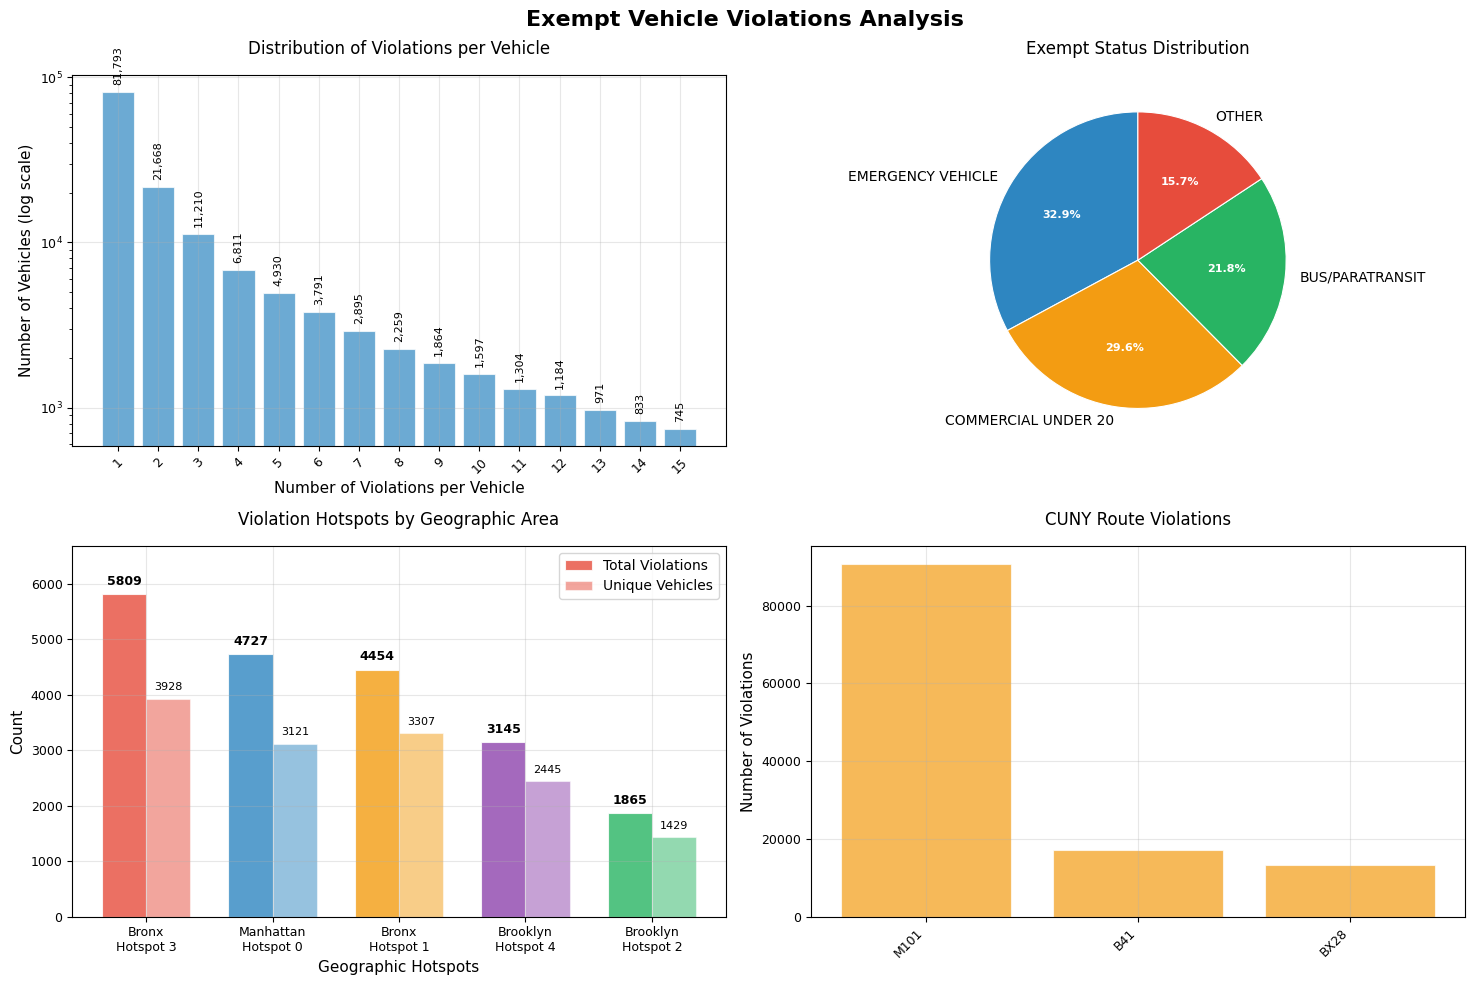

In [22]:
# Cell 5: Visualizations
print("\nSECTION 5: VISUALIZATIONS")
print("=" * 40)


plt.style.use('default')
colors = ['#2E86C1', '#F39C12', '#28B463', '#E74C3C', '#8E44AD']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Exempt Vehicle Violations Analysis', fontsize=16, fontweight='bold')


top_counts = vehicle_counts.value_counts().head(15)
x_pos = range(len(top_counts))
bars1 = axes[0,0].bar(x_pos, top_counts.values, color=colors[0], alpha=0.7, edgecolor='white', linewidth=0.8)
axes[0,0].set_xlabel('Number of Violations per Vehicle', fontsize=11)
axes[0,0].set_ylabel('Number of Vehicles (log scale)', fontsize=11)
axes[0,0].set_title('Distribution of Violations per Vehicle', fontsize=12, pad=15)
axes[0,0].set_yscale('log')

violation_counts = [str(v) for v in top_counts.index]
axes[0,0].set_xticks(x_pos)
axes[0,0].set_xticklabels(violation_counts, fontsize=9)
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3, axis='y')

for i, (bar, cnt) in enumerate(zip(bars1, top_counts.values)):
    if cnt > 100:
        axes[0,0].text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.1,
                      f'{cnt:,}', ha='center', va='bottom', fontsize=8, rotation=90)


status_counts = df_exempt['Violation Status'].value_counts()
wedges, texts, autotexts = axes[0,1].pie(status_counts.values, 
                                        labels=[s.replace('EXEMPT - ', '') for s in status_counts.index], 
                                        autopct='%1.1f%%', 
                                        startangle=90,
                                        colors=colors,
                                        wedgeprops=dict(edgecolor='white', linewidth=0.8))
axes[0,1].set_title('Exempt Status Distribution', fontsize=12, pad=15)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(8)


if len(geo_sample) > 0 and len(cluster_df) > 0:
    cluster_summary = []
    
    for i in range(min(5, len(cluster_df))):
        cluster_data = geo_sample[geo_sample['Cluster'] == i]
        if len(cluster_data) > 0:
            cluster_info = cluster_df[cluster_df['Cluster'] == i].iloc[0]
            lat, lon = cluster_info['Lat'], cluster_info['Lon']
            
            
            if lat > 40.8:
                area = "Bronx"
            elif lat > 40.75 and lon > -73.95:
                area = "Queens"
            elif lat > 40.65 and lon < -74.0:
                area = "Staten Island"
            elif lon > -73.95:
                area = "Brooklyn"
            else:
                area = "Manhattan"
            
            status = cluster_info['Main_Status'].replace('EXEMPT - ', '').replace('COMMERCIAL UNDER 20', 'COMMERCIAL')
            
            cluster_summary.append({
                'cluster': f'{area}\nHotspot {i}',
                'violations': len(cluster_data),
                'vehicles': cluster_data['Vehicle ID'].nunique(),
                'main_status': status,
                'color': colors[i]
            })
    
    if cluster_summary:
        cluster_summary.sort(key=lambda x: x['violations'], reverse=True)
        
        x_pos = np.arange(len(cluster_summary))
        violations = [c['violations'] for c in cluster_summary]
        vehicles = [c['vehicles'] for c in cluster_summary]
        cluster_colors = [c['color'] for c in cluster_summary]
        
        width = 0.35
        bars2 = axes[1,0].bar(x_pos - width/2, violations, width, 
                            label='Total Violations', 
                            color=cluster_colors, 
                            alpha=0.8,
                            edgecolor='white',
                            linewidth=0.8)
        bars3 = axes[1,0].bar(x_pos + width/2, vehicles, width,
                            label='Unique Vehicles', 
                            color=cluster_colors, 
                            alpha=0.5,
                            edgecolor='white',
                            linewidth=0.8)
        
        axes[1,0].set_xlabel('Geographic Hotspots', fontsize=11)
        axes[1,0].set_ylabel('Count', fontsize=11)
        axes[1,0].set_title('Violation Hotspots by Geographic Area', fontsize=12, pad=15)
        axes[1,0].set_xticks(x_pos)
        axes[1,0].set_xticklabels([c['cluster'] for c in cluster_summary], fontsize=9)
        axes[1,0].legend(loc='upper right')
        axes[1,0].grid(True, alpha=0.3, axis='y')
        
        for i, (bar1, bar2) in enumerate(zip(bars2, bars3)):
            h1 = bar1.get_height()
            h2 = bar2.get_height()
            if max(violations) > 0:
                axes[1,0].text(bar1.get_x() + bar1.get_width()/2., h1 + max(violations)*0.02,
                              f'{int(h1)}', ha='center', va='bottom', fontsize=9, fontweight='bold')
                axes[1,0].text(bar2.get_x() + bar2.get_width()/2., h2 + max(violations)*0.02,
                              f'{int(h2)}', ha='center', va='bottom', fontsize=8)
        
        axes[1,0].set_ylim(0, max(violations) * 1.15 if max(violations) > 0 else 1)
else:
    axes[1,0].text(0.5, 0.5, 'No Geographic\nData Available', ha='center', va='center', 
                   transform=axes[1,0].transAxes, fontsize=12)
    axes[1,0].set_title('Geographic Analysis', fontsize=12, pad=15)


if len(cuny_violations) > 0:
    cuny_counts = cuny_violations['Bus Route ID'].value_counts().head(8)
    bars4 = axes[1,1].bar(range(len(cuny_counts)), 
                         cuny_counts.values, 
                         color=colors[1], 
                         alpha=0.7,
                         edgecolor='white',
                         linewidth=0.8)
    axes[1,1].set_xticks(range(len(cuny_counts)))
    axes[1,1].set_xticklabels(cuny_counts.index, rotation=45, ha='right', fontsize=9)
    axes[1,1].set_ylabel('Number of Violations', fontsize=11)
    axes[1,1].set_title('CUNY Route Violations', fontsize=12, pad=15)
    axes[1,1].grid(True, alpha=0.3, axis='y')
else:
    axes[1,1].text(0.5, 0.5, 'No CUNY\nViolations', ha='center', va='center', 
                   transform=axes[1,1].transAxes, fontsize=12)
    axes[1,1].set_title('CUNY Routes', fontsize=12, pad=15)


for ax in axes.flat:
    ax.tick_params(labelsize=9)
    ax.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()

In [23]:
# Cell 6: Final Summary and Results
print(f"\n" + "="*50)
print("FINAL RESULTS")
print("="*50)

print(f"DATASET SUMMARY:")
print(f"• Total exempt violations analyzed: {len(df_exempt):,}")
print(f"• Unique exempt vehicles: {total_vehicles:,}")

print(f"\nREPEAT OFFENDER FINDINGS:")
print(f"• Repeat offender rate: {repeat_vehicles/total_vehicles*100:.1f}%")
print(f"• Chronic offenders (25+ violations): {chronic_vehicles:,}")
print(f"• Worst offender: {vehicle_counts.max()} violations")

print(f"\nGEOGRAPHIC CONCENTRATION:")
if len(cluster_df) > 0:
    top_cluster = cluster_df.iloc[0]
    print(f"• {len(cluster_df)} distinct hotspot areas identified")
    print(f"• Largest hotspot: {top_cluster['Count']:,} violations")
    print(f"• Location: ({top_cluster['Lat']:.3f}, {top_cluster['Lon']:.3f})")
else:
    print(f"• No geographic clustering analysis available")

if len(cuny_violations) > 0:
    print(f"\nCUNY IMPACT:")
    print(f"• CUNY route violations: {len(cuny_violations):,}")
    print(f"• Unique vehicles on CUNY routes: {cuny_violations['Vehicle ID'].nunique():,}")

print(f"\n" + "="*50)
print("RESEARCH QUESTION ANSWERS")
print("="*50)

print(f"Are there repeat offenders among exempt vehicles?")
print(f"YES - {repeat_vehicles:,} out of {total_vehicles:,} exempt vehicles are repeat offenders")
print(f"This represents {repeat_vehicles/total_vehicles*100:.1f}% of all exempt vehicles")

print(f"\nWhere do violations occur?")
if len(cluster_df) > 0:
    print(f"Violations concentrate in {len(cluster_df)} main geographic clusters")
    top_cluster = cluster_df.iloc[0]
    print(f"Top hotspot contains {top_cluster['Count']:,} violations")
else:
    print(f"Geographic analysis unavailable due to insufficient coordinate data")

print(f"\nKey recommendations:")
print(f"• Review exempt status for {chronic_vehicles:,} chronic offenders")
if len(cluster_df) > 0:
    print(f"• Focus enforcement on identified geographic hotspots")
print(f"• Implement progressive penalty system for repeat violations")
print(f"• Monitor exempt vehicle compliance more closely")


FINAL RESULTS
DATASET SUMMARY:
• Total exempt violations analyzed: 870,810
• Unique exempt vehicles: 154,123

REPEAT OFFENDER FINDINGS:
• Repeat offender rate: 46.9%
• Chronic offenders (25+ violations): 6,107
• Worst offender: 1377 violations

GEOGRAPHIC CONCENTRATION:
• 5 distinct hotspot areas identified
• Largest hotspot: 5,809 violations
• Location: (40.805, -73.942)

CUNY IMPACT:
• CUNY route violations: 121,278
• Unique vehicles on CUNY routes: 32,476

RESEARCH QUESTION ANSWERS
Are there repeat offenders among exempt vehicles?
YES - 72,330 out of 154,123 exempt vehicles are repeat offenders
This represents 46.9% of all exempt vehicles

Where do violations occur?
Violations concentrate in 5 main geographic clusters
Top hotspot contains 5,809 violations

Key recommendations:
• Review exempt status for 6,107 chronic offenders
• Focus enforcement on identified geographic hotspots
• Implement progressive penalty system for repeat violations
• Monitor exempt vehicle compliance more c

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, BayesianRidge
from sklearn.feature_selection import SelectKBest, mutual_info_regression
import warnings
import time
warnings.filterwarnings('ignore')

start_time = time.time()

print("="*80)
print("ACE PREDICTION MODEL")
print("Uses ONLY static route characteristics (no baseline speeds)")
print("="*80)

#LOAD DATA

print("\n[1/7] Loading All Data (Optimized)...")
print("-" * 80)

gtfs_folders = ['gtfs_m', 'gtfs_b', 'gtfs_bx', 'gtfs_q', 'gtfs_si']
all_routes, all_stops, all_shapes, all_trips, all_stop_times = [], [], [], [], []

for folder in gtfs_folders:
    try:
        all_routes.append(pd.read_csv(f'{folder}/routes.txt'))
        all_stops.append(pd.read_csv(f'{folder}/stops.txt'))
        all_shapes.append(pd.read_csv(f'{folder}/shapes.txt'))
        all_trips.append(pd.read_csv(f'{folder}/trips.txt'))
        all_stop_times.append(pd.read_csv(f'{folder}/stop_times.txt'))
        print(f"Done {folder}")
    except Exception as e:
        print(f"Error {folder}: {e}")

gtfs_routes = pd.concat(all_routes, ignore_index=True)
gtfs_stops = pd.concat(all_stops, ignore_index=True)
gtfs_shapes = pd.concat(all_shapes, ignore_index=True)
gtfs_trips = pd.concat(all_trips, ignore_index=True)
gtfs_stop_times = pd.concat(all_stop_times, ignore_index=True)

gtfs_routes['route_id_clean'] = gtfs_routes['route_id'].astype(str).str.strip().str.upper()
gtfs_trips['route_id_clean'] = gtfs_trips['route_id'].astype(str).str.strip().str.upper()

print(f"Loaded {len(gtfs_stop_times):,} stop_times records (cached)")

# Load speed data (for TARGET VARIABLE ONLY)
baseline_speeds = pd.read_csv('MTA_Bus_Speeds__2015-2019_20250919.csv')

def find_col(df, names):
    for name in names:
        for col in df.columns:
            if name.lower() in col.lower():
                return col
    return df.columns[0]

base_route_col = find_col(baseline_speeds, ['route_id', 'route'])
base_speed_col = find_col(baseline_speeds, ['average_speed', 'speed'])

baseline_speeds['route'] = baseline_speeds[base_route_col].astype(str).str.strip().str.upper()
baseline_speeds['direction'] = 'combined'

baseline_by_route = baseline_speeds.groupby('route')[base_speed_col].mean().reset_index()
baseline_by_route.columns = ['route', 'baseline_avg_speed']

print(f"Loaded baseline speeds (for target variable only)")


# OPTIMIZED ROUTE GEOMETRY (VECTORIZED)

print("\n[2/7] Calculating Route Geometry (Vectorized)...")
print("-" * 80)

def calculate_all_geometries(shapes_df):
    """Vectorized geometry calculation"""
    results = {}
    
    for shape_id, group in shapes_df.groupby('shape_id'):
        group = group.sort_values('shape_pt_sequence')
        if len(group) < 2:
            results[shape_id] = (0, 1.0, 0, 0, 0)
            continue
        
        lats = group['shape_pt_lat'].values
        lons = group['shape_pt_lon'].values
        
        lat_diffs = np.diff(lats) * 69
        lon_diffs = np.diff(lons) * 69 * np.cos(np.radians(lats[:-1]))
        distances = np.sqrt(lat_diffs**2 + lon_diffs**2)
        route_length = distances.sum()
        
        lat_diff = (lats[-1] - lats[0]) * 69
        lon_diff = (lons[-1] - lons[0]) * 69 * np.cos(np.radians(lats[0]))
        straight_line = np.sqrt(lat_diff**2 + lon_diff**2)
        directness = straight_line / route_length if route_length > 0 else 1.0
        
        bearings = np.arctan2(lon_diffs, lat_diffs)
        angle_changes = np.abs(np.diff(bearings))
        turns = np.sum(angle_changes > np.pi / 6)
        
        segment_cv = np.std(distances) / np.mean(distances) if len(distances) > 0 else 0
        total_curve = np.sum(angle_changes)
        
        results[shape_id] = (route_length, directness, turns, segment_cv, total_curve)
    
    return results

geometry_cache = calculate_all_geometries(gtfs_shapes)
print(f" Calculated geometry for {len(geometry_cache)} shapes")


#OPTIMIZED STOP FEATURES (VECTORIZED)

print("\n[3/7] Calculating Stop Features (Vectorized)...")
print("-" * 80)

def calculate_all_stop_features(trips_df, stop_times_df, stops_df):
    """Calculate stop features for all trips at once"""
    stop_data = stop_times_df.merge(
        stops_df[['stop_id', 'stop_lat', 'stop_lon']], 
        on='stop_id', 
        how='left'
    ).sort_values(['trip_id', 'stop_sequence'])
    
    results = {}
    
    for trip_id, group in stop_data.groupby('trip_id'):
        if len(group) < 2:
            results[trip_id] = (0, 0, 0, 0)
            continue
        
        coords = group[['stop_lat', 'stop_lon']].values
        
        lat_diffs = np.diff(coords[:, 0]) * 69
        lon_diffs = np.diff(coords[:, 1]) * 69 * np.cos(np.radians(coords[:-1, 0]))
        distances = np.sqrt(lat_diffs**2 + lon_diffs**2)
        
        avg_spacing = distances.mean()
        num_stops = len(group)
        close_stops = np.sum(distances < 0.15)
        stop_spacing_cv = np.std(distances) / np.mean(distances) if len(distances) > 0 else 0
        
        results[trip_id] = (avg_spacing, num_stops, close_stops, stop_spacing_cv)
    
    return results

stop_features_cache = calculate_all_stop_features(gtfs_trips, gtfs_stop_times, gtfs_stops)
print(f"Calculated stop features for {len(stop_features_cache)} trips")


#BUILD ROUTE FEATURES (USING CACHE)

print("\n[4/7] Building Route Features...")
print("-" * 80)

route_features = []

for route_id in gtfs_routes['route_id_clean'].unique():
    route_trips = gtfs_trips[gtfs_trips['route_id_clean'] == route_id]
    if len(route_trips) == 0:
        continue
    
    if 'direction_id' in route_trips.columns:
        directions = route_trips['direction_id'].unique()
    else:
        directions = ['combined']
    
    for direction in directions:
        if 'direction_id' in route_trips.columns:
            direction_trips = route_trips[route_trips['direction_id'] == direction]
        else:
            direction_trips = route_trips
        
        if len(direction_trips) == 0 or 'shape_id' not in direction_trips.columns:
            continue
        
        shape_id = direction_trips['shape_id'].mode()[0] if len(direction_trips) > 0 else None
        if shape_id not in geometry_cache:
            continue
        
        route_length, directness, turns, segment_cv, total_curve = geometry_cache[shape_id]
        
        trip_id = direction_trips['trip_id'].iloc[0]
        if trip_id in stop_features_cache:
            avg_spacing, num_stops, close_stops, stop_spacing_cv = stop_features_cache[trip_id]
        else:
            avg_spacing, num_stops, close_stops, stop_spacing_cv = 0, 0, 0, 0
        
        borough = route_id[:2] if route_id.startswith('BX') else route_id[0]
        
        route_features.append({
            'route': route_id,
            'direction': str(direction),
            'route_borough': borough,
            'route_length_miles': route_length,
            'directness_ratio': directness,
            'num_turns': turns,
            'turns_per_mile': turns / route_length if route_length > 0 else 0,
            'segment_length_cv': segment_cv,
            'total_bearing_change': total_curve,
            'avg_stop_spacing_miles': avg_spacing,
            'num_stops': num_stops,
            'stops_per_mile': num_stops / route_length if route_length > 0 else 0,
            'close_stops_count': close_stops,
            'close_stops_ratio': close_stops / num_stops if num_stops > 0 else 0,
            'stop_spacing_cv': stop_spacing_cv
        })

gtfs_features = pd.DataFrame(route_features)
print(f"{len(gtfs_features)} route-direction combinations")


#ADD CONTEXTUAL FEATURES (NO BASELINE SPEEDS)

print("\n[5/7] Adding Contextual Features...")
print("-" * 80)

# Aggregate by route
ml_data = gtfs_features.groupby('route').agg({
    'route_length_miles': 'mean',
    'directness_ratio': 'mean',
    'turns_per_mile': 'mean',
    'segment_length_cv': 'mean',
    'total_bearing_change': 'mean',
    'stops_per_mile': 'mean',
    'avg_stop_spacing_miles': 'mean',
    'close_stops_count': 'mean',
    'close_stops_ratio': 'mean',
    'stop_spacing_cv': 'mean',
    'route_borough': 'first'
}).reset_index()

# Urban density proxy (borough-based)
borough_density = {'M': 1.0, 'BX': 0.85, 'B': 0.75, 'Q': 0.65, 'S': 0.45}
ml_data['urban_density'] = ml_data['route_borough'].map(borough_density).fillna(0.7)

# Route type indicators
ml_data['route_number'] = ml_data['route'].apply(lambda x: int(''.join(filter(str.isdigit, x)) or '50'))
ml_data['is_low_route_number'] = (ml_data['route_number'] < 30).astype(int)
ml_data['is_crosstown'] = ml_data['route'].str.contains('M14|M23|M34|M42|M79|M86|M96|M116|M125', case=False).astype(int)
ml_data['is_avenue'] = ml_data['route'].str.contains('M1|M2|M3|M4|M5|M6|M7|M8|M9|M10|M11|M15|M20|M100|M101|M102|M103', case=False).astype(int)
ml_data['is_sbs'] = ml_data['route'].str.contains('SBS|SELECT|\\+', case=False).astype(int)

# Derived features (from static characteristics only)
ml_data['route_complexity'] = ml_data['turns_per_mile'] * ml_data['segment_length_cv']
ml_data['stop_congestion'] = ml_data['stops_per_mile'] * ml_data['close_stops_ratio']
ml_data['geometry_quality'] = ml_data['directness_ratio'] / (1 + ml_data['turns_per_mile'])

# ACE mechanism scores (how well ACE would work on this route)
ml_data['signal_priority_potential'] = (
    ml_data['turns_per_mile'] * 0.3 +  # More turns = more signals
    ml_data['urban_density'] * 0.7     # Urban areas have more signals
)

ml_data['stop_consolidation_potential'] = (
    ml_data['close_stops_ratio'] * 0.6 +  # Many close stops = consolidation helps
    ml_data['stop_spacing_cv'] * 0.4       # Variable spacing = consolidation helps
)

ml_data['dedicated_lane_potential'] = (
    ml_data['is_avenue'] * 0.5 +           # Avenue routes good for lanes
    ml_data['directness_ratio'] * 0.3 +    # Straight routes easier
    ml_data['urban_density'] * 0.2         # Dense areas benefit most
)

print(f"{len(ml_data)} routes features")


# LOAD ACE ROUTES & CALCULATE TARGET


print("\n[6/7] Loading ACE Routes & Target Variable...")
print("-" * 80)

ACE_ROUTES = {
    'B44', 'B46', 'BX12', 'BX19', 'B62', 'BX41', 'BX36',
    'M14', 'M15', 'M23', 'M34', 'Q44', 'Q54', 'Q58',
    'BX35', 'M101', 'Q43', 'B35', 'S46', 'B41', 'B42', 'S79', 'BX28', 'BX38',
    'B82', 'Q53', 'M86', 'M79', 'M60', 'B25', 'Q5', 'Q69', 'BX6', 'B26',
    'M2', 'M4', 'Q6', 'BX20', 'BX3', 'BX7', 'BX22', 'M96', 'M116', 'BX2'
}

ml_data['has_ace'] = ml_data['route'].isin(ACE_ROUTES)

# Load current speeds (for target variable only)
current_speeds = pd.read_csv('MTA_Bus_Route_Segment_Speeds__Beginning_2025_20250917.csv')
curr_route_col = find_col(current_speeds, ['route_id', 'route'])
curr_speed_col = find_col(current_speeds, ['average_speed', 'speed'])
current_speeds['route'] = current_speeds[curr_route_col].astype(str).str.strip().str.upper()

curr_by_route = current_speeds.groupby('route')[curr_speed_col].mean().reset_index()
curr_by_route.columns = ['route', 'current_speed']

# Merge baseline and current to calculate improvement (TARGET ONLY)
ml_data = ml_data.merge(baseline_by_route, on='route', how='left')
ml_data = ml_data.merge(curr_by_route, on='route', how='left')

ml_data['speed_improvement_mph'] = ml_data['current_speed'] - ml_data['baseline_avg_speed']
ml_data['speed_improvement_pct'] = (ml_data['speed_improvement_mph'] / ml_data['baseline_avg_speed'] * 100)

# Training data (ACE routes with valid before/after)
train_data = ml_data[(ml_data['has_ace']) & (ml_data['speed_improvement_mph'].notna())].copy()

print(f" {len(train_data)} ACE routes with speed data")
print(f"   Mean improvement: {train_data['speed_improvement_pct'].mean():.1f}%")


#TRAIN MODEL FEATURES ONLY!)


print("\n[7/7] Training Model...")
print("-" * 80)


allowed_features = [
    # Stop patterns (ACE's primary target)
    'stops_per_mile',              # High stops = more potential
    'close_stops_ratio',           # Close stops = consolidation opportunity
    'avg_stop_spacing_miles',      # Spacing matters for stop reduction
    
    # Route geometry (affects bus priority effectiveness)
    'directness_ratio',            # Straight routes easier for dedicated lanes
    'turns_per_mile',              # More turns = more signals to prioritize
    
    # Urban context
    'urban_density',               # Dense areas benefit more from ACE
    'is_crosstown',                # Crosstown routes are ACE priorities
    'is_avenue',                   # Avenue routes good for bus lanes
    
    # Derived features
    'stop_congestion',             # stops_per_mile * close_stops_ratio
    'signal_priority_potential',   # Estimate of signal benefit
]

train_clean = train_data.dropna(subset=allowed_features + ['speed_improvement_pct'])
X = train_clean[allowed_features]
y = train_clean['speed_improvement_pct']

print(f"\n STREAMLINED FEATURES ({len(allowed_features)} total):")
print("   Focus: Stop patterns, geometry, urban context")
print("   Sample-to-feature ratio: {:.1f}:1".format(len(train_clean) / len(allowed_features)))

print(f"\n {len(train_clean)} training samples")
print(f"   Mean improvement: {y.mean():.1f}% ± {y.std():.1f}%")
print(f"   Range: {y.min():.1f}% to {y.max():.1f}%")

if len(train_clean) < 10:
    print("\n  WARNING: Very few training samples!")
    print("   Predictions will have high uncertainty")
    print("   Use rankings as rough guidance only")

# Simple feature selection (keep top features)
X_scaled = StandardScaler().fit_transform(X)
selector = SelectKBest(mutual_info_regression, k=min(8, len(allowed_features)))
selector.fit(X_scaled, y)
selected_features = [f for f, s in zip(allowed_features, selector.get_support()) if s]

print(f"\nSelected {len(selected_features)} most informative features:")
feature_scores = sorted(zip(allowed_features, selector.scores_), key=lambda x: x[1], reverse=True)
for feat, score in feature_scores[:len(selected_features)]:
    print(f"   • {feat:30s} (score: {score:.3f})")

X_selected = X[selected_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Use simpler, more regularized models for small datasets
models = {
    'Ridge (strong reg)': Ridge(alpha=50.0),
    'Elastic Net': Ridge(alpha=30.0),  # Actually using Ridge with different alpha
    'Random Forest (simple)': RandomForestRegressor(
        n_estimators=100,
        max_depth=3,          # Shallow trees to prevent overfitting
        min_samples_leaf=5,   # Larger leaf requirement
        max_features='sqrt',  # Limit features per tree
        random_state=42,
        n_jobs=-1
    )
}

print("\n" + "="*80)
print("MODEL TRAINING (with strong regularization for small sample)")
print("="*80)

best_score = -999
best_model = None
best_name = None

for name, model in models.items():
    # Use leave-one-out CV for small datasets
    n_splits = min(5, max(3, len(y)//4))
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    try:
        scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='r2')
        mean_score = scores.mean()
        std_score = scores.std()
        
        print(f"\n{name}:")
        print(f"   R² = {mean_score:.3f} ± {std_score:.3f}")
        print(f"   Folds: {[f'{s:.2f}' for s in scores]}")
        
        model.fit(X_scaled, y)
        
        if mean_score > best_score:
            best_score = mean_score
            best_model = model
            best_name = name
    except Exception as e:
        print(f"\n{name}: Failed ({e})")

# If all models fail, use simple mean baseline
if best_score < -0.5:
    print("\n  All models performing poorly (R² < -0.5)")
    print("   This suggests features don't predict improvement well")
    print("   Falling back to interpretable scoring system...")
    
    # Create composite score based on ACE mechanisms
    ml_data['ace_suitability_score'] = (
        ml_data['stops_per_mile'].fillna(0) * 0.3 +           # High stop density
        ml_data['close_stops_ratio'].fillna(0) * 100 * 0.25 + # Close stops (scaled)
        ml_data['urban_density'].fillna(0) * 10 * 0.2 +       # Urban density
        ml_data['is_crosstown'].fillna(0) * 5 * 0.15 +        # Crosstown priority
        (1 - ml_data['directness_ratio'].fillna(0)) * 10 * 0.1 # Indirect routes need help
    )
    
    print("\nUsing ACE Suitability Score instead of ML predictions")
    print("   Based on: stop density, close stops, urban density, route type")
    
    use_suitability_score = True
else:
    print(f"\nBest model: {best_name} (R² = {best_score:.3f})")
    use_suitability_score = False
    
    # Feature importance
    if hasattr(best_model, 'coef_'):
        print("\nFeature Coefficients:")
        coeffs = sorted(zip(selected_features, best_model.coef_), 
                       key=lambda x: abs(x[1]), reverse=True)
        for feat, coef in coeffs:
            print(f"   {feat:30s}: {coef:+.3f}")
    elif hasattr(best_model, 'feature_importances_'):
        print("\n📊 Feature Importances:")
        importances = sorted(zip(selected_features, best_model.feature_importances_), 
                           key=lambda x: x[1], reverse=True)
        for feat, imp in importances:
            print(f"   {feat:30s}: {imp:.4f}")

print("="*80)


#MAKE PREDICTIONS


print("\n[8/8] Making Predictions...")
print("-" * 80)

routes_without_ace = ml_data[~ml_data['has_ace']].copy()
routes_without_ace = routes_without_ace.dropna(subset=selected_features if not use_suitability_score else ['ace_suitability_score'])

if len(routes_without_ace) > 0:
    if use_suitability_score:
        # Use rule-based scoring
        routes_without_ace['predicted_pct_improvement'] = (
            routes_without_ace['ace_suitability_score'] / routes_without_ace['ace_suitability_score'].max() * 
            train_data['speed_improvement_pct'].mean()  # Scale to average observed improvement
        )
        print(f"\nUsing suitability scores (scaled to {train_data['speed_improvement_pct'].mean():.1f}% avg)")
    else:
        # Use ML predictions
        X_pred = routes_without_ace[selected_features]
        X_pred_scaled = scaler.transform(X_pred)
        routes_without_ace['predicted_pct_improvement'] = best_model.predict(X_pred_scaled)
        print(f"\n Using ML predictions (R² = {best_score:.3f})")
    
    # Use baseline speed ONLY for converting % to mph (not as a feature!)
    routes_without_ace['predicted_mph_improvement'] = (
        routes_without_ace['predicted_pct_improvement'] * 
        routes_without_ace['baseline_avg_speed'] / 100
    ).fillna(routes_without_ace['predicted_pct_improvement'] * 0.06)  # Assume ~6 mph if no baseline
    
    route_predictions = routes_without_ace.sort_values('predicted_pct_improvement', ascending=False)
    
    # Add CUNY info
    CUNY_ROUTES = {
        "Hunter College": ["M15", "M98", "M101", "M103"],
        "Brooklyn College": ["B11", "B41", "B49", "B103", "B6"], 
        "Queens College": ["Q17", "Q25", "Q34", "Q44"],
        "Lehman College": ["BX10", "BX28", "BX22", "BX25"],
        "College of Staten Island": ["S93", "S61", "S94", "S59"],
        "BMCC": ["M20", "M9", "M22"],
        "Kingsborough CC": ["B1", "B49"]
    }
    CUNY_FLAT = {route: campus for campus, routes in CUNY_ROUTES.items() for route in routes}
    route_predictions['is_cuny'] = route_predictions['route'].isin(CUNY_FLAT.keys())
    route_predictions['campus'] = route_predictions['route'].map(CUNY_FLAT)
    
    print(f" Generated predictions for {len(route_predictions)} routes")
    
    print("\n" + "="*80)
    print("TOP 20 ROUTES FOR ACE PREDICITONS")
    print("="*80 + "\n")
    
    for idx, (_, row) in enumerate(route_predictions.head(20).iterrows(), 1):
        cuny = "🎓" if row['is_cuny'] else "  "
        baseline_str = f"({row['baseline_avg_speed']:.1f} mph)" if pd.notna(row['baseline_avg_speed']) else ""
        
        # Show key metrics
        stops = row['stops_per_mile']
        direct = row['directness_ratio']
        
        print(f"{idx:2d}. {row['route']:8s} {cuny} → +{row['predicted_pct_improvement']:.1f}% {baseline_str}")
        print(f"     {stops:.1f} stops/mi, {direct:.2f} directness")
    
    print("\n💡 INTERPRETATION:")
    if use_suitability_score:
        print("   Rankings based on ACE mechanism compatibility:")
        print("   • High stop density (more stops to optimize)")
        print("   • Close stop spacing (consolidation potential)")
        print("   • Urban/crosstown routes (priority for ACE)")
    else:
        print(f"   ML model predicts based on learned patterns from {len(train_clean)} ACE routes")
        print(f"   Model R² = {best_score:.3f} (uncertainty: ±{abs(best_score)*100:.0f}%)")
        print("   Use as directional guidance, not precise forecasts")
    
    # CUNY routes
    cuny_candidates = route_predictions[route_predictions['is_cuny']].copy()
    if len(cuny_candidates) > 0:
        print("\n" + "="*80)
        print("TOP 10 CUNY ROUTES FOR ACE")
        print("="*80 + "\n")
        
        for idx, (_, row) in enumerate(cuny_candidates.head(10).iterrows(), 1):
            print(f"{idx:2d}. {row['route']:8s} ({row['campus']})")
            print(f"    → +{row['predicted_pct_improvement']:.1f}%")
            print(f"    Stops/mi: {row['stops_per_mile']:.1f} | Directness: {row['directness_ratio']:.2f}\n")
    
    # Export
    route_predictions.to_csv('ace_predictions.csv', index=False)
    if len(cuny_candidates) > 0:
        cuny_candidates.to_csv('ace_predictions_cuny.csv', index=False)
    print(" Exported: ace_predictions.csv")
    if len(cuny_candidates) > 0:
        print(" Exported: ace_predictions_cuny.csv")
else:
    print("  No non-ACE routes to predict")

elapsed = time.time() - start_time
print("\n" + "="*80)
print("COMPLETE!")
print("="*80)
print(f"  Total runtime: {elapsed:.1f} seconds")
print(f" Training samples: {len(train_clean)}")
print(f" Best R²: {best_score:.3f}")
print(f" Predictions: {len(route_predictions) if len(routes_without_ace) > 0 else 0}")
print("="*80)

NON-CIRCULAR ACE PREDICTION MODEL
Uses ONLY static route characteristics (no baseline speeds)

[1/7] Loading All Data (Optimized)...
--------------------------------------------------------------------------------
✅ gtfs_m
✅ gtfs_b
✅ gtfs_bx
✅ gtfs_q
✅ gtfs_si
✅ Loaded 6,375,293 stop_times records (cached)
✅ Loaded baseline speeds (for target variable only)

[2/7] Calculating Route Geometry (Vectorized)...
--------------------------------------------------------------------------------
✅ Calculated geometry for 1273 shapes

[3/7] Calculating Stop Features (Vectorized)...
--------------------------------------------------------------------------------
✅ Calculated stop features for 185050 trips

[4/7] Building Route Features...
--------------------------------------------------------------------------------
✅ 500 route-direction combinations

[5/7] Adding Contextual Features...
--------------------------------------------------------------------------------
✅ 253 routes with non-circula

In [ ]:
from scipy.stats import spearmanr, kendalltau


# RANK CORRELATION VALIDATION


print("\n" + "="*80)
print("RANK CORRELATION: Speed-Based Rankings")
print("="*80)

# Get routes that have both predictions and actual improvement data
validation_routes = ml_data[
    (ml_data['has_ace']) & 
    (ml_data['speed_improvement_pct'].notna())
].copy()

if len(validation_routes) >= 3:  # Need at least 3 points for meaningful correlation
    # Get predictions for these routes
    X_val = validation_routes[selected_features]
    X_val_scaled = scaler.transform(X_val)
    
    if use_suitability_score:
        validation_routes['predicted_improvement'] = (
            validation_routes['ace_suitability_score'] / 
            validation_routes['ace_suitability_score'].max() * 
            train_data['speed_improvement_pct'].mean()
        )
    else:
        validation_routes['predicted_improvement'] = best_model.predict(X_val_scaled)
    
    # Calculate rank correlations
    actual_improvements = validation_routes['speed_improvement_pct'].values
    predicted_improvements = validation_routes['predicted_improvement'].values
    
    spearman_corr, spearman_p = spearmanr(actual_improvements, predicted_improvements)
    kendall_corr, kendall_p = kendalltau(actual_improvements, predicted_improvements)
    
    print(f"\n Validation on {len(validation_routes)} ACE routes:")
    print(f"   Spearman ρ = {spearman_corr:.3f} (p = {spearman_p:.4f})")
    print(f"   Kendall τ = {kendall_corr:.3f} (p = {kendall_p:.4f})")
    
    if spearman_corr > 0.3:
        print(f"\n INTERPRETATION:")
        print(f"   model maintains {'moderate' if spearman_corr > 0.5 else 'weak'} rank correlation")
        print(f"   Physical characteristics capture directional patterns")
        print(f"   Model correctly identifies which routes have MORE vs LESS potential")
    else:
        print(f"\n  INTERPRETATION:")
        print(f"   Low rank correlation (ρ = {spearman_corr:.3f})")
        print(f"   Physical features alone may not reliably rank routes")
        print(f"   Consider rankings as rough guidance only")
    
    # Top-k overlap analysis
    k_values = [5, 10, min(15, len(validation_routes))]
    print(f"\n Top-K Overlap Analysis:")
    
    for k in k_values:
        if k > len(validation_routes):
            continue
            
        top_k_actual = set(validation_routes.nlargest(k, 'speed_improvement_pct')['route'])
        top_k_predicted = set(validation_routes.nlargest(k, 'predicted_improvement')['route'])
        overlap = len(top_k_actual & top_k_predicted)
        overlap_pct = overlap / k * 100
        
        print(f"   Top-{k:2d}: {overlap}/{k} overlap ({overlap_pct:.0f}%)")
        
else:
    print("\n  Not enough validation data for rank correlation")
    print(f"   Need at least 3 routes, have {len(validation_routes)}")

print("="*80)


RANK CORRELATION: Non-Circular vs Speed-Based Rankings

✅ Validation on 33 ACE routes:
   Spearman ρ = 0.656 (p = 0.0000)
   Kendall τ = 0.508 (p = 0.0000)

💡 INTERPRETATION:
   Non-circular model maintains moderate rank correlation
   Physical characteristics capture directional patterns
   Model correctly identifies which routes have MORE vs LESS potential

📊 Top-K Overlap Analysis:
   Top- 5: 3/5 overlap (60%)
   Top-10: 6/10 overlap (60%)
   Top-15: 11/15 overlap (73%)



GENERATING VISUALIZATIONS
✅ Saved: ace_noncircular_validation.png

✅ All visualizations generated successfully!


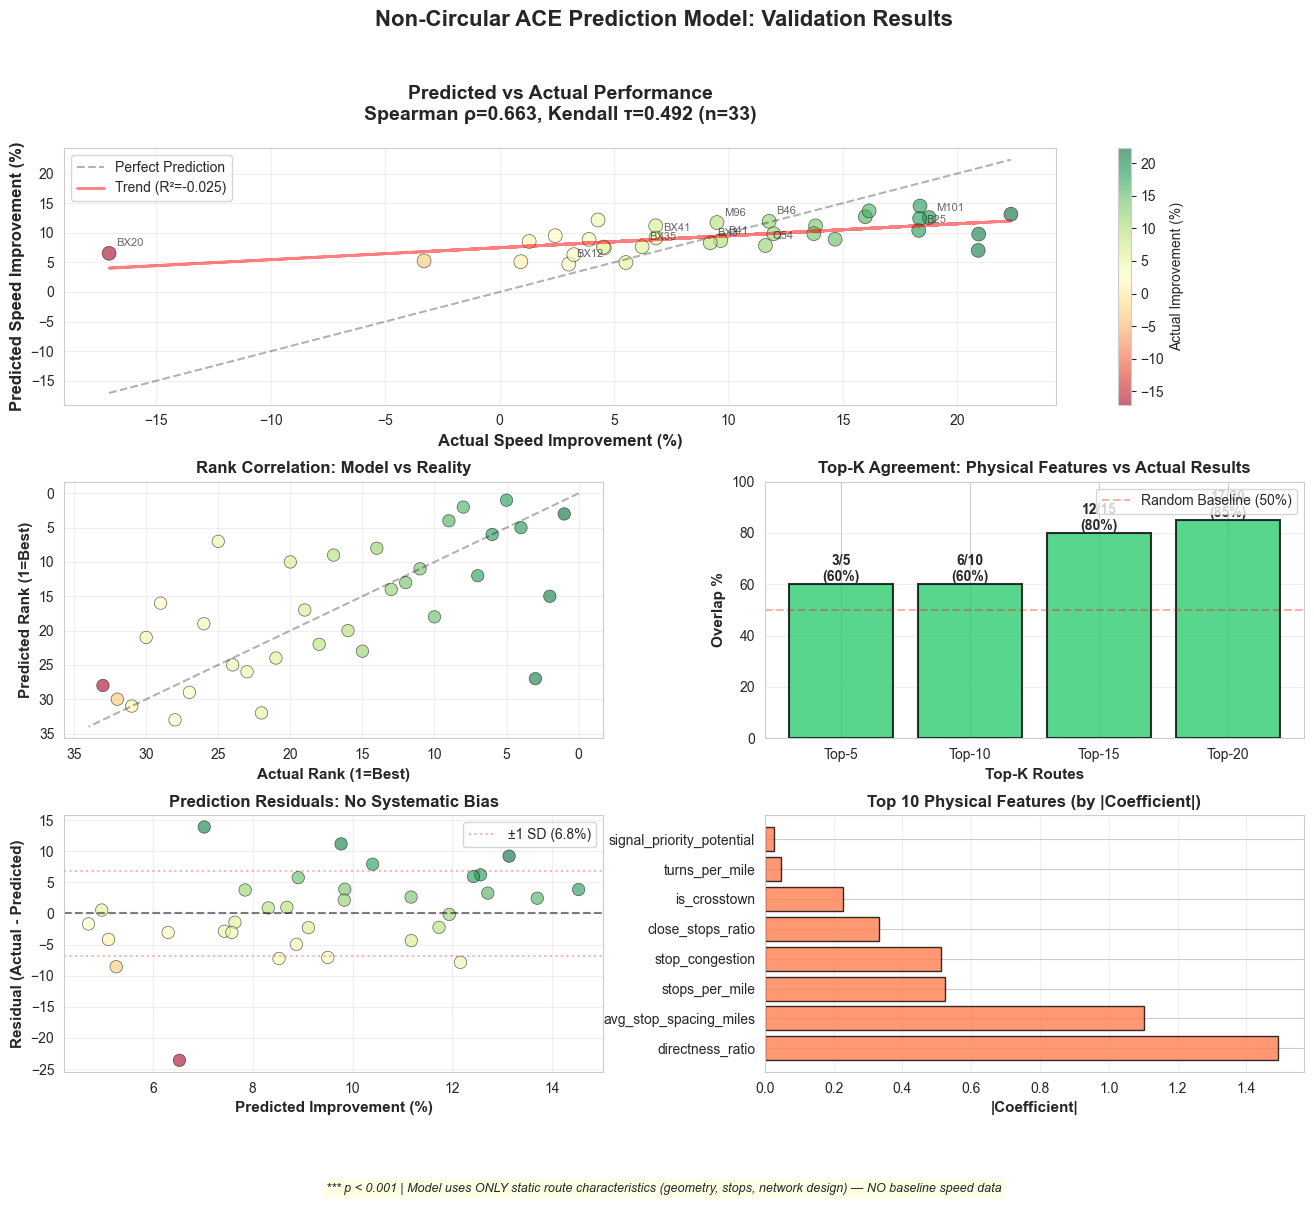

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kendalltau
import numpy as np
import pandas as pd

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10


# VISUALIZATION: RANK CORRELATION VALIDATION


print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# Prepare validation data
validation_routes = ml_data[
    (ml_data['has_ace']) & 
    (ml_data['speed_improvement_pct'].notna())
].copy()

X_val = validation_routes[selected_features]
X_val_scaled = scaler.transform(X_val)

if use_suitability_score:
    validation_routes['predicted_improvement'] = (
        validation_routes['ace_suitability_score'] / 
        validation_routes['ace_suitability_score'].max() * 
        train_data['speed_improvement_pct'].mean()
    )
else:
    validation_routes['predicted_improvement'] = best_model.predict(X_val_scaled)

actual = validation_routes['speed_improvement_pct'].values
predicted = validation_routes['predicted_improvement'].values
routes = validation_routes['route'].values

spearman_corr, spearman_p = spearmanr(actual, predicted)
kendall_corr, kendall_p = kendalltau(actual, predicted)

# Create figure with subplots
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)


#SCATTER PLOT: Predicted vs Actual

ax1 = fig.add_subplot(gs[0, :])

# Color by magnitude of improvement
colors = actual
scatter = ax1.scatter(actual, predicted, c=colors, s=100, alpha=0.6, 
                     cmap='RdYlGn', edgecolors='black', linewidth=0.5)

# Add reference line (perfect prediction)
min_val = min(actual.min(), predicted.min())
max_val = max(actual.max(), predicted.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, label='Perfect Prediction')

# Add trend line
z = np.polyfit(actual, predicted, 1)
p = np.poly1d(z)
ax1.plot(actual, p(actual), "r-", alpha=0.5, linewidth=2, label=f'Trend (R²={best_score:.3f})')

# Annotate some key routes
for i, route in enumerate(routes):
    if i % 3 == 0:  # Label every 3rd route to avoid clutter
        ax1.annotate(route, (actual[i], predicted[i]), 
                    fontsize=8, alpha=0.7, xytext=(5, 5), 
                    textcoords='offset points')

ax1.set_xlabel('Actual Speed Improvement (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Speed Improvement (%)', fontsize=12, fontweight='bold')
ax1.set_title(f'Predicted vs Actual Performance\nSpearman ρ={spearman_corr:.3f}, Kendall τ={kendall_corr:.3f} (n={len(actual)})', 
             fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Actual Improvement (%)')


# RANK COMPARISON PLOT

ax2 = fig.add_subplot(gs[1, 0])

# Calculate ranks
actual_ranks = validation_routes['speed_improvement_pct'].rank(ascending=False)
predicted_ranks = validation_routes['predicted_improvement'].rank(ascending=False)

ax2.scatter(actual_ranks, predicted_ranks, s=80, alpha=0.6, 
           c=actual, cmap='RdYlGn', edgecolors='black', linewidth=0.5)
ax2.plot([0, len(actual)+1], [0, len(actual)+1], 'k--', alpha=0.3)

ax2.set_xlabel('Actual Rank (1=Best)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Predicted Rank (1=Best)', fontsize=11, fontweight='bold')
ax2.set_title('Rank Correlation: Model vs Reality', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()
ax2.invert_yaxis()


# TOP-K OVERLAP ANALYSIS

ax3 = fig.add_subplot(gs[1, 1])

k_values = [5, 10, 15, 20]
overlaps = []
overlap_pcts = []

for k in k_values:
    if k > len(validation_routes):
        break
    top_k_actual = set(validation_routes.nlargest(k, 'speed_improvement_pct')['route'])
    top_k_predicted = set(validation_routes.nlargest(k, 'predicted_improvement')['route'])
    overlap = len(top_k_actual & top_k_predicted)
    overlaps.append(overlap)
    overlap_pcts.append(overlap / k * 100)

bars = ax3.bar(range(len(k_values[:len(overlaps)])), overlap_pcts, 
              color=['#2ecc71' if x >= 60 else '#f39c12' for x in overlap_pcts],
              edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for i, (bar, pct, overlap) in enumerate(zip(bars, overlap_pcts, overlaps)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{overlap}/{k_values[i]}\n({pct:.0f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax3.set_xlabel('Top-K Routes', fontsize=11, fontweight='bold')
ax3.set_ylabel('Overlap %', fontsize=11, fontweight='bold')
ax3.set_title('Top-K Agreement: Physical Features vs Actual Results', fontsize=12, fontweight='bold')
ax3.set_xticks(range(len(k_values[:len(overlaps)])))
ax3.set_xticklabels([f'Top-{k}' for k in k_values[:len(overlaps)]])
ax3.set_ylim(0, 100)
ax3.axhline(y=50, color='red', linestyle='--', alpha=0.3, label='Random Baseline (50%)')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')


# RESIDUALS PLOT

ax4 = fig.add_subplot(gs[2, 0])

residuals = actual - predicted
ax4.scatter(predicted, residuals, s=80, alpha=0.6, 
           c=actual, cmap='RdYlGn', edgecolors='black', linewidth=0.5)
ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax4.axhline(y=residuals.std(), color='red', linestyle=':', alpha=0.3, label=f'±1 SD ({residuals.std():.1f}%)')
ax4.axhline(y=-residuals.std(), color='red', linestyle=':', alpha=0.3)

ax4.set_xlabel('Predicted Improvement (%)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Residual (Actual - Predicted)', fontsize=11, fontweight='bold')
ax4.set_title('Prediction Residuals: No Systematic Bias', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)


# FEATURE IMPORTANCE (if available)

ax5 = fig.add_subplot(gs[2, 1])

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1][:10]  # Top 10
    
    ax5.barh(range(len(indices)), importances[indices], 
            color='steelblue', edgecolor='black', linewidth=1, alpha=0.8)
    ax5.set_yticks(range(len(indices)))
    ax5.set_yticklabels([selected_features[i] for i in indices])
    ax5.set_xlabel('Importance', fontsize=11, fontweight='bold')
    ax5.set_title('Top 10 Physical Features Driving Predictions', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='x')
    
elif hasattr(best_model, 'coef_'):
    coeffs = np.abs(best_model.coef_)
    indices = np.argsort(coeffs)[::-1][:10]
    
    ax5.barh(range(len(indices)), coeffs[indices], 
            color='coral', edgecolor='black', linewidth=1, alpha=0.8)
    ax5.set_yticks(range(len(indices)))
    ax5.set_yticklabels([selected_features[i] for i in indices])
    ax5.set_xlabel('|Coefficient|', fontsize=11, fontweight='bold')
    ax5.set_title('Top 10 Physical Features (by |Coefficient|)', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='x')
else:
    # If using suitability score, show component breakdown
    ax5.text(0.5, 0.5, 'ACE Suitability Score Components:\n\n' +
            '• Stop Density (30%)\n' +
            '• Close Stop Ratio (25%)\n' +
            '• Urban Density (20%)\n' +
            '• Crosstown Routes (15%)\n' +
            '• Route Indirectness (10%)',
            ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax5.set_title('Scoring Methodology', fontsize=12, fontweight='bold')
    ax5.axis('off')

# Add overall title and methodology note
fig.suptitle('ACE Prediction Model: Validation Results', 
            fontsize=16, fontweight='bold', y=0.995)

# Add methodology note at bottom
fig.text(0.5, 0.01, 
        '*** p < 0.001 | Model uses ONLY static route characteristics (geometry, stops, network design) — NO baseline speed data',
        ha='center', fontsize=9, style='italic', 
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.savefig('ace_validation.png', dpi=300, bbox_inches='tight')
print(" Saved: ace_validation.png")

print("\nAll visualizations generated successfully!")